# Buried Resources: Municipal Waste Recovery Across Countries

This notebook downloads the World Bank's country-level What a Waste 3.0 workbook and WDI indicators. It then validates the files, selects comparable observations, explores the data, matches peer countries, estimates benchmark scenarios, and checks sensitivity to the number of peers. 

In [1]:
from __future__ import annotations
import hashlib, json, math, urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'pyproject.toml').is_file() and (ROOT.parent / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise FileNotFoundError('Start Jupyter from the repository root or its notebooks directory.')
RAW = ROOT / 'data' / 'raw'
OUT = ROOT / 'outputs'
RAW.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT.name)


Project root: buried_resources 8


In [2]:
WAW_URL = "https://datacatalogfiles.worldbank.org/ddh-published/0039597/DR0095901/What_a_Waste_3.0_COUNTRY_Dataset_%26_Codebook.xlsx"


API = "https://api.worldbank.org/v2/country/all/indicator/{code}?format=json&per_page=20000&date=2015:2024"


INDICATORS = {"gdp_pc_ppp": "NY.GDP.PCAP.PP.KD", "urban_pct": "SP.URB.TOTL.IN.ZS"}


GEN = "msw_total_msw_generated_tonnes_year"


YEAR = "msw_total_msw_generation_year"


COMP = ["composition_msw_" + x + "_percent" for x in (
    "food_organic_waste", "glass", "metal", "paper_cardboard", "plastic", "rubber_leather",
    "wood", "yard_garden_green_waste", "textile_waste", "weee", "hazardous",
    "diapers_and_hygiene", "other")]


ELIGIBLE = ["composition_msw_" + x + "_percent" for x in (
    "food_organic_waste", "glass", "metal", "paper_cardboard", "plastic", "yard_garden_green_waste")]


TREAT = ["waste_treatment_" + x + "_percent" for x in (
    "open_dumpsite", "controlled_landfill", "sanitary_landfill_landfill_gas_system",
    "landfill_unspecified", "anaerobic_digestion", "compost", "recycling", "incineration",
    "mbt", "rdf", "other", "unaccounted_for")]


UNC = "waste_uncollected_percent"


COVER = "waste_collection_coverage_total_percent_of_waste"


RECOVERY = ["waste_treatment_" + x + "_percent" for x in ("anaerobic_digestion", "compost", "recycling")]


def download(url: str, path: Path, kind: str) -> dict:
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        req = urllib.request.Request(url, headers={"User-Agent": "buried-resources-research/0.1"})
        with urllib.request.urlopen(req, timeout=90) as response:
            data = response.read(35_000_001)
            if len(data) > 35_000_000:
                raise ValueError(f"Oversize download: {url}")
        path.write_bytes(data)
    b = path.read_bytes()
    if kind == "xlsx" and not b.startswith(b"PK\x03\x04"):
        raise ValueError(f"Expected XLSX ZIP bytes: {url}")
    if kind == "json" and not b.lstrip().startswith(b"["):
        raise ValueError(f"Expected JSON list: {url}")
    return {"url": url, "bytes": len(b), "sha256": hashlib.sha256(b).hexdigest(), "file": path.name}


def read_waw(path: Path) -> pd.DataFrame:
    wb = load_workbook(path, read_only=True, data_only=True)
    if "Country dataset" not in wb.sheetnames or "Codebook" not in wb.sheetnames:
        raise ValueError("Missing country data sheet or codebook")
    rows = wb["Country dataset"].values
    next(rows)  # descriptive labels
    keys = [str(x).strip() if x is not None else "" for x in next(rows)]
    required = {"iso3c", "country_name", "region_id", GEN, YEAR, UNC, COVER, *COMP, *TREAT}
    if not required.issubset(keys) or len(keys) != len(set(keys)):
        raise ValueError(f"Missing or repeated columns: {sorted(required - set(keys))}")
    frame = pd.DataFrame(rows, columns=keys)
    frame = frame[frame.iso3c.notna()].copy()
    if frame.iso3c.duplicated().any() or not frame.iso3c.astype(str).str.fullmatch(r"[A-Z]{3}").all():
        raise ValueError("Nonunique or malformed ISO3 codes")
    for col in [GEN, YEAR, UNC, COVER, *COMP, *TREAT]:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame


def read_wdi(path: Path, indicator: str) -> pd.DataFrame:
    obj = json.loads(path.read_text())
    if not isinstance(obj, list) or len(obj) != 2 or obj[0].get("pages") != 1 or not isinstance(obj[1], list):
        raise ValueError(f"Invalid or paginated WDI response: {indicator}")
    rows = []
    for item in obj[1]:
        if item["indicator"]["id"] != indicator:
            raise ValueError("Wrong WDI indicator")
        if item["value"] is not None and len(item["countryiso3code"]) == 3:
            rows.append((item["countryiso3code"], int(item["date"]), float(item["value"])))
    if not rows:
        raise ValueError("Empty WDI indicator")
    return pd.DataFrame(rows, columns=["iso3c", "year", "value"])


In [3]:
audit = {'waw': download(WAW_URL, RAW / 'waw3_country.xlsx', 'xlsx')}
wdi = {}
for label, indicator in INDICATORS.items():
    path = RAW / f'wdi_{indicator}.json'
    audit[label] = download(API.format(code=indicator), path, 'json')
    wdi[label] = read_wdi(path, indicator)
raw = read_waw(RAW / 'waw3_country.xlsx')
display(pd.DataFrame(audit).T[['bytes', 'sha256']])
print('Countries and economies in the source workbook:', len(raw))
display(raw[['iso3c', 'country_name', YEAR, GEN]].head())


,bytes,sha256
waw,7268712,42ec5fb213bbf79b9f6d860c24da3d19fc7f7e0ed274fd...
gdp_pc_ppp,658571,7e370e7b164bdf90e0962f2b71be6fc854be25c30ff209...
urban_pct,630143,afa059e2752704c65ecd8b6d494dcb2062fb8874a9a29d...


Countries and economies in the source workbook: 217


,iso3c,country_name,msw_total_msw_generation_year,msw_total_msw_generated_tonnes_year
0,AFG,Afghanistan,2017.0,4.148162e+06
1,ALB,Albania,2021.0,7.540940e+05
2,DZA,Algeria,2020.0,1.350000e+07
3,ASM,American Samoa,2019.0,1.734817e+04
4,AND,Andorra,2021.0,3.795000e+04


In [4]:
def validate_and_prepare(raw: pd.DataFrame, wdi: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    x = raw.copy()
    diagnostics = {}
    def gate(name, valid):
        nonlocal x
        valid = valid.fillna(False)
        diagnostics[name] = {"before": len(x), "retained": int(valid.sum()), "excluded": int((~valid).sum())}
        x = x.loc[valid].copy()

    gate("positive_generation_and_valid_year", (x[GEN] > 0) & x[YEAR].between(2010, 2024))
    # Percent variables are decimal fractions in the actual spreadsheet.
    values = x[COMP + TREAT + [UNC, COVER]]
    gate("fractions_within_zero_one", (values.isna() | ((values >= 0) & (values <= 1.000001))).all(axis=1))
    comp_total = x[COMP].sum(axis=1, min_count=1)
    gate("composition_closure_95_105pct", comp_total.between(.95, 1.05) & x[ELIGIBLE].notna().any(axis=1))
    x["eligible_share"] = x[ELIGIBLE].fillna(0).sum(axis=1)
    gate("plausible_eligible_fraction", x.eligible_share.between(.01, 1))
    treat_cols = TREAT + [UNC]
    treat_total = x[treat_cols].sum(axis=1, min_count=1)
    gate("treatment_closure_95_105pct", treat_total.between(.95, 1.05))
    x["uncollected_share"] = x[UNC]
    fallback = x.uncollected_share.isna() & x[COVER].notna()
    x.loc[fallback, "uncollected_share"] = 1 - x.loc[fallback, COVER]
    x["coverage_source"] = np.where(x[UNC].notna(), "uncollected_mass_share", np.where(fallback, "collected_mass_share", "missing"))
    gate("mass_based_collection_coverage", x.uncollected_share.between(0, 1))
    x["collection_share"] = 1 - x.uncollected_share
    x["recovery_share"] = x[RECOVERY].fillna(0).sum(axis=1)
    gate("mass_balance_recovery_feasible", (x.recovery_share <= x.eligible_share * x.collection_share + .01) & (x.recovery_share <= x.collection_share + .01))
    # Closest observed WDI year to the WAW observation year; ties choose earlier.
    for name, table in wdi.items():
        grouped = {iso: g for iso, g in table.groupby("iso3c")}
        selected = []
        years = []
        for iso, year in zip(x.iso3c, x[YEAR]):
            g = grouped.get(iso)
            if g is None:
                selected.append(np.nan); years.append(np.nan); continue
            g = g.assign(distance=(g.year - int(year)).abs()).sort_values(["distance", "year"])
            best = g.iloc[0]
            selected.append(best.value if best.distance <= 3 else np.nan)
            years.append(best.year if best.distance <= 3 else np.nan)
        x[name] = selected
        x[name + "_year"] = years
    gate("wdi_within_three_years", x.gdp_pc_ppp.gt(0) & x.urban_pct.between(0, 100))
    x["capture_given_collection"] = (x.recovery_share / (x.eligible_share * x.collection_share).replace(0, np.nan)).clip(upper=1)
    gate("positive_collection", x.capture_given_collection.notna())
    x["eligible_tonnes"] = x[GEN] * x.eligible_share
    x["recovered_tonnes_proxy"] = x[GEN] * x.recovery_share
    x["unrecovered_eligible_tonnes_proxy"] = (x.eligible_tonnes - x.recovered_tonnes_proxy).clip(lower=0)
    x["collection_gap_proxy"] = x.eligible_tonnes * x.uncollected_share
    x["treatment_gap_proxy"] = (x.eligible_tonnes * x.collection_share - x.recovered_tonnes_proxy).clip(lower=0)
    x["recovery_efficiency_proxy"] = x.recovery_share / x.eligible_share
    cols = ["iso3c", "country_name", "region_id", YEAR, GEN, "gdp_pc_ppp", "gdp_pc_ppp_year", "urban_pct", "urban_pct_year", "eligible_share", "collection_share", "coverage_source", "recovery_share", "capture_given_collection", "recovery_efficiency_proxy", "eligible_tonnes", "recovered_tonnes_proxy", "unrecovered_eligible_tonnes_proxy", "collection_gap_proxy", "treatment_gap_proxy"]
    metrics = x[cols].rename(columns={GEN: "waste_tonnes_year", YEAR: "waste_year"}).reset_index(drop=True)
    return x, metrics, diagnostics


,check,before,retained,excluded
0,positive_generation_and_valid_year,217,200,17
1,fractions_within_zero_one,200,200,0
2,composition_closure_95_105pct,200,172,28
3,plausible_eligible_fraction,172,172,0
4,treatment_closure_95_105pct,172,153,19
5,mass_based_collection_coverage,153,88,65
6,mass_balance_recovery_feasible,88,86,2
7,wdi_within_three_years,86,84,2
8,positive_collection,84,84,0


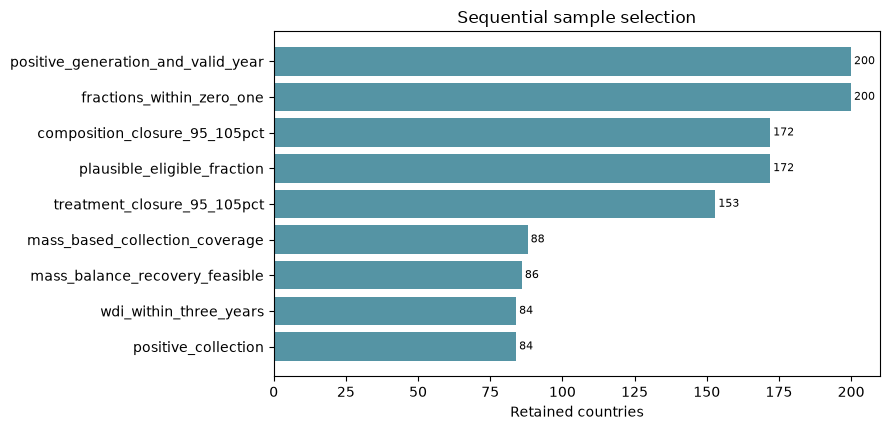

In [5]:
_, metrics, flow = validate_and_prepare(raw, wdi)
flow_table = pd.DataFrame([{'check': key, **value} for key, value in flow.items()])
display(flow_table)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(flow_table['check'][::-1], flow_table['retained'][::-1], color='#5594a4')
ax.set(xlabel='Retained countries', title='Sequential sample selection')
for y, n in enumerate(flow_table['retained'][::-1]):
    ax.text(n + 1, y, str(n), va='center', fontsize=8)
fig.tight_layout()
plt.show()


## Explore observation years and waste composition



,iso3c,waste_year,eligible_share,collection_share,recovery_share,recovery_efficiency_proxy
0,AFG,2017.0,0.723400,0.592000,0.254000,0.351120
1,ALB,2021.0,0.833000,0.917762,0.173337,0.208088
2,ATG,2012.0,0.851000,0.990000,0.000000,0.000000
3,ARG,2022.0,0.777700,0.980000,0.000000,0.000000
4,AZE,2020.0,0.754500,0.680000,0.000000,0.000000
5,BGD,2021.0,0.745500,0.806300,0.031446,0.042181
6,BRB,2021.0,0.729000,0.900000,0.042800,0.058711
7,BLZ,2015.0,0.740000,0.727700,0.000000,0.000000
8,BTN,2019.0,0.868827,0.671739,0.237269,0.273090
9,BWA,2017.0,0.130100,0.763149,0.006291,0.048352


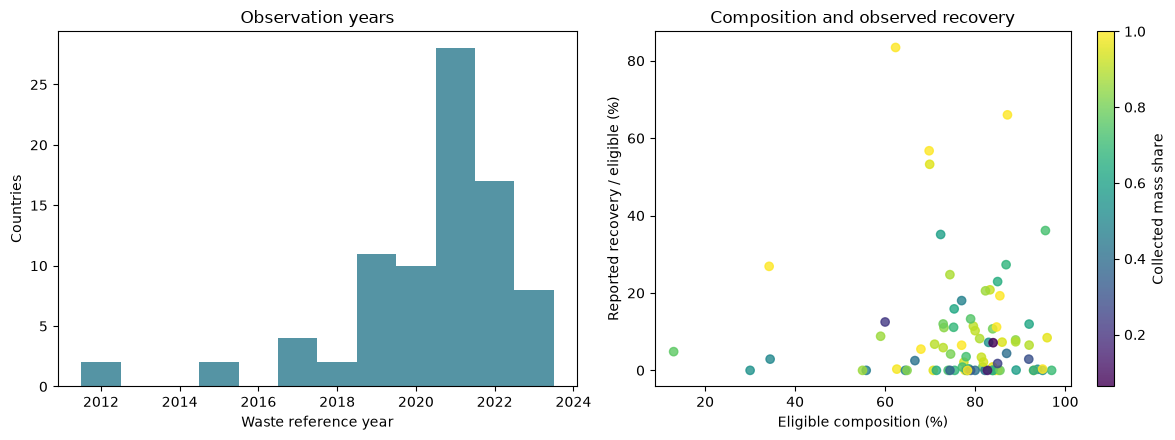

In [6]:
display(metrics[['iso3c', 'waste_year', 'eligible_share', 'collection_share',
                 'recovery_share', 'recovery_efficiency_proxy']].head(10))
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4.5))
a.hist(metrics.waste_year, bins=np.arange(2011.5, 2024.5, 1), color='#5594a4')
a.set(xlabel='Waste reference year', ylabel='Countries', title='Observation years')
scatter = b.scatter(metrics.eligible_share * 100, metrics.recovery_efficiency_proxy * 100,
                    c=metrics.collection_share, cmap='viridis', alpha=.8)
b.set(xlabel='Eligible composition (%)', ylabel='Reported recovery / eligible (%)',
      title='Composition and observed recovery')
fig.colorbar(scatter, ax=b, label='Collected mass share')
fig.tight_layout()
plt.show()


## Match peer countries and decompose benchmark scenarios

The nearest-neighbor distance uses log GDP per capita, urban population share, and the share of selected potentially recoverable components. Each country is compared with its eight closest peers.

In [7]:
def peer_scenarios(metrics: pd.DataFrame, k: int = 8, minimum: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Match without conditioning on outcome. Robust scale prevents a single feature dominating.
    z = np.column_stack([np.log(metrics.gdp_pc_ppp), metrics.urban_pct / 100, metrics.eligible_share])
    center = np.median(z, axis=0)
    scale = np.subtract(*np.percentile(z, [75, 25], axis=0))
    scale = np.where(scale > 1e-8, scale, 1)
    z = (z - center) / scale
    peers = []
    scenarios = []
    for i, target in metrics.iterrows():
        d = np.linalg.norm(z - z[i], axis=1)
        d[i] = np.inf
        nearest = np.argsort(d)[:k]
        if len(nearest) < minimum or not np.isfinite(d[nearest[-1]]):
            continue
        pool = metrics.iloc[nearest]
        for rank, j in enumerate(nearest, start=1):
            peers.append({"iso3c": target.iso3c, "peer_iso3c": metrics.iloc[j].iso3c, "rank": rank, "scaled_distance": float(d[j])})
        c_star = max(target.collection_share, float(pool.collection_share.quantile(.75)))
        t_star = max(target.capture_given_collection, float(pool.capture_given_collection.quantile(.75)))
        # Sequential attribution: expand collection at current capture, then improve capture.
        collection_gain = target.eligible_tonnes * (c_star - target.collection_share) * target.capture_given_collection
        treatment_gain = target.eligible_tonnes * c_star * (t_star - target.capture_given_collection)
        reduction = collection_gain + treatment_gain
        scenarios.append({"iso3c": target.iso3c, "country_name": target.country_name,
            "peer_count": len(nearest), "peer_p75_collection": float(pool.collection_share.quantile(.75)),
            "peer_p75_capture": float(pool.capture_given_collection.quantile(.75)),
            "target_collection": c_star, "target_capture": t_star,
            "collection_gain_tonnes_proxy": collection_gain, "treatment_gain_tonnes_proxy": treatment_gain,
            "additional_recovery_tonnes_proxy": reduction,
            "remaining_unrecovered_tonnes_proxy": max(0, target.unrecovered_eligible_tonnes_proxy - reduction),
            "priority": "no_measured_peer_gap" if reduction <= 1e-9 else
                        ("collection" if collection_gain > treatment_gain else "sorting_and_biological_treatment")})
    return pd.DataFrame(peers), pd.DataFrame(scenarios)


In [8]:
peers, scenarios = peer_scenarios(metrics, k=8)
summary = {
    'source_countries': len(raw), 'analyzed_countries': len(metrics),
    'peer_scenarios': len(scenarios),
    'waste_year_min': int(metrics.waste_year.min()),
    'waste_year_max': int(metrics.waste_year.max()),
    'total_additional_recovery_tonnes_proxy': float(scenarios.additional_recovery_tonnes_proxy.sum()),
}
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))
display(scenarios.sort_values('additional_recovery_tonnes_proxy', ascending=False).head(10))


,value
source_countries,2.170000e+02
analyzed_countries,8.400000e+01
peer_scenarios,8.400000e+01
waste_year_min,2.012000e+03
waste_year_max,2.023000e+03
total_additional_recovery_tonnes_proxy,1.272553e+08


,iso3c,country_name,peer_count,peer_p75_collection,peer_p75_capture,target_collection,target_capture,collection_gain_tonnes_proxy,treatment_gain_tonnes_proxy,additional_recovery_tonnes_proxy,remaining_unrecovered_tonnes_proxy,priority
14,CHN,China,8,0.894339,0.157250,0.997000,0.157250,0.000000e+00,6.650530e+07,6.650530e+07,3.576954e+08,sorting_and_biological_treatment
30,IND,India,8,0.733275,0.089430,0.954000,0.089430,0.000000e+00,1.219962e+07,1.219962e+07,1.307940e+08,sorting_and_biological_treatment
60,SAU,Saudi Arabia,8,1.000000,0.559968,1.000000,0.559968,0.000000e+00,7.123163e+06,7.123163e+06,6.205293e+06,sorting_and_biological_treatment
10,BRA,Brazil,8,0.985000,0.117265,0.985000,0.117265,7.904154e+04,5.907996e+06,5.987037e+06,5.608036e+07,sorting_and_biological_treatment
72,THA,Thailand,8,0.969250,0.083948,0.969250,0.499818,3.174044e+06,0.000000e+00,3.174044e+06,1.328555e+07,collection
71,TZA,Tanzania,8,0.835400,0.070729,0.835400,0.570776,3.124219e+06,0.000000e+00,3.124219e+06,4.645781e+06,collection
31,IDN,Indonesia,8,0.884100,0.086809,0.884100,0.254029,2.746289e+06,0.000000e+00,2.746289e+06,3.239157e+07,collection
42,MEX,Mexico,8,0.936289,0.191913,0.936289,0.191913,4.502368e+05,1.957808e+06,2.408045e+06,2.857785e+07,sorting_and_biological_treatment
58,RUS,Russian Federation,8,0.999213,0.132252,0.999213,0.132252,3.583047e+05,2.023930e+06,2.382235e+06,3.542745e+07,sorting_and_biological_treatment
32,IRQ,Iraq,8,0.937571,0.157250,0.937571,0.157250,6.750686e+03,2.351950e+06,2.358701e+06,1.370521e+07,sorting_and_biological_treatment


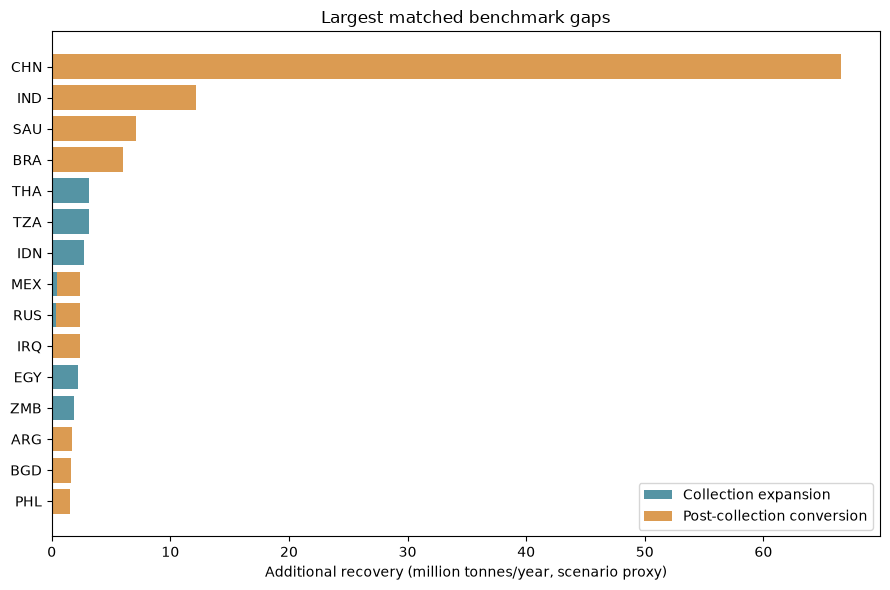

In [9]:
top = scenarios.nlargest(15, 'additional_recovery_tonnes_proxy').sort_values('additional_recovery_tonnes_proxy')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.iso3c, top.collection_gain_tonnes_proxy / 1e6,
        label='Collection expansion', color='#5594a4')
ax.barh(top.iso3c, top.treatment_gain_tonnes_proxy / 1e6,
        left=top.collection_gain_tonnes_proxy / 1e6,
        label='Post-collection conversion', color='#db9b52')
ax.set(xlabel='Additional recovery (million tonnes/year, scenario proxy)',
       title='Largest matched benchmark gaps')
ax.legend()
fig.tight_layout()
plt.show()


## Sensitivity to the number of peers


,peer_count,countries,total_additional_million_tonnes_proxy,zero_gap_countries
0,5,84,154.867414,8
1,8,84,127.255311,8
2,12,84,141.301545,7


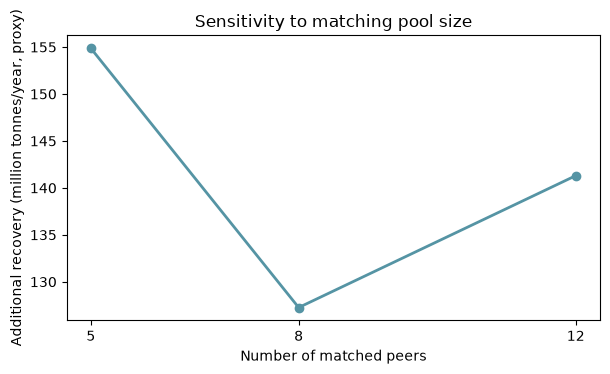

In [10]:
sensitivity = []
for count in [5, 8, 12]:
    match, scenario = peer_scenarios(metrics, k=count)
    sensitivity.append({'peer_count': count, 'countries': len(scenario),
        'total_additional_million_tonnes_proxy': scenario.additional_recovery_tonnes_proxy.sum() / 1e6,
        'zero_gap_countries': int((scenario.additional_recovery_tonnes_proxy <= 1e-9).sum())})
sensitivity = pd.DataFrame(sensitivity)
display(sensitivity)
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(sensitivity.peer_count, sensitivity.total_additional_million_tonnes_proxy,
        marker='o', linewidth=2, color='#5594a4')
ax.set(xticks=[5,8,12], xlabel='Number of matched peers',
       ylabel='Additional recovery (million tonnes/year, proxy)',
       title='Sensitivity to matching pool size')
fig.tight_layout()
fig.savefig(OUT / 'peer_sensitivity.png', dpi=140)
plt.show()


In [11]:
pd.DataFrame([{'gate': k, **v} for k, v in flow.items()]).to_csv(OUT/'sample_flow.csv', index=False)
metrics.to_csv(OUT/'country_metrics.csv', index=False)
peers.to_csv(OUT/'peer_matches.csv', index=False)
scenarios.to_csv(OUT/'scenario.csv', index=False)
sensitivity.to_csv(OUT/'notebook_sensitivity.csv', index=False)
(OUT/'source_audit.json').write_text(json.dumps(audit, indent=2), encoding='utf-8')
print('Saved:', ', '.join(['sample_flow.csv', 'country_metrics.csv', 'peer_matches.csv',
                           'scenario.csv', 'notebook_sensitivity.csv', 'source_audit.json']))


Saved: sample_flow.csv, country_metrics.csv, peer_matches.csv, scenario.csv, notebook_sensitivity.csv, source_audit.json
